<a href="https://colab.research.google.com/github/antavarez/titan-tracker-research/blob/main/vix_dca_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_3858/2110475054.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy_raw = yf.download('SPY', start='2000-01-01', end=today)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_3858/2110475054.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix_raw = yf.download('^VIX', start='2000-01-01', end=today)
[*********************100%***********************]  1 of 1 completed


SPY row: 6598
VIX row: 6598
High VIX: n=252, mean 3m return = 4.55%
Normal VIX: n=652, mean 3m return = 1.48%
T-statistic: 4.831, p-value: 0.0000
Result: Statistically significant difference detected


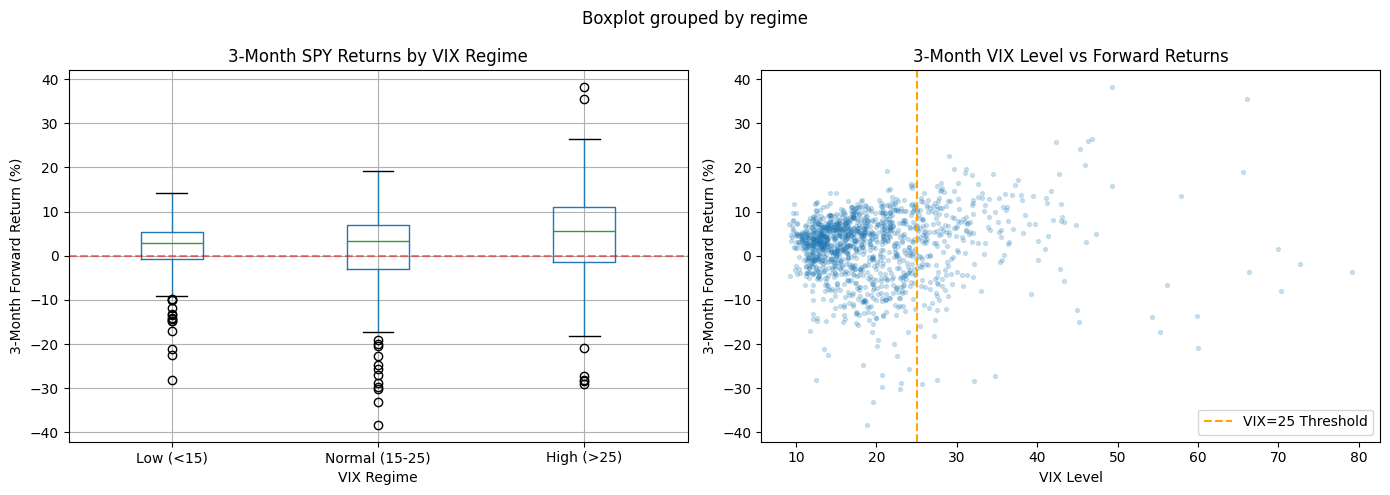

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from datetime import date

#Download SPY + VIX data
#(2000-2026)
today = date.today().strftime('%Y-%m-%d')
spy_raw = yf.download('SPY', start='2000-01-01', end=today)
vix_raw = yf.download('^VIX', start='2000-01-01', end=today)
spy =spy_raw['Close'].squeeze()
vix = vix_raw['Close'].squeeze()
print("SPY row:", len(spy))
print("VIX row:", len(vix))

#weekly data
df = pd.DataFrame({'SPY': spy, 'VIX': vix}).dropna ()
df_weekly = df.resample('W').last().dropna()
#13-week (3-month) forward returns
df_weekly['forward_3m'] = df_weekly['SPY'].pct_change(13).shift(-13)*100
#VIX regimes
df_weekly['regime'] = pd.cut(df_weekly['VIX'],
                             bins=[0, 15, 25, 100],
                             labels=['Low (<15)', 'Normal (15-25)', 'High (>25)'])
df_clean = df_weekly.dropna()

# T-test: High VIX vs Normal VIX forward returns
high = df_clean[df_clean['regime'] == 'High (>25)']['forward_3m']
normal = df_clean[df_clean['regime'] == 'Normal (15-25)']['forward_3m']
#stats. # This line was incomplete and commented out

t_stat, p_value = stats.ttest_ind(high, normal)

print(f"High VIX: n={len(high)}, mean 3m return = {high.mean():.2f}%")
print(f"Normal VIX: n={len(normal)}, mean 3m return = {normal.mean():.2f}%")
print(f"T-statistic: {t_stat:.3f}, p-value: {p_value:.4f}")
if p_value < 0.05:
      print("Result: Statistically significant difference detected")
else:
      print("Result: No statisticslly significant difference")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_clean.boxplot(column='forward_3m', by='regime', ax=axes[0])
axes[0].set_title('3-Month SPY Returns by VIX Regime')
axes[0].set_xlabel('VIX Regime')
axes[0].set_ylabel('3-Month Forward Return (%)')
axes[0].axhline(y=0, color='r',linestyle='--', alpha=0.5)

axes[1].scatter(df_clean['VIX'], df_clean['forward_3m'], alpha=0.2, s=8)
axes[1].axvline(x=25, color='orange', linestyle='--', label='VIX=25 Threshold')
axes[1].set_xlabel('VIX Level') # Corrected: changed } to ]
axes[1].set_ylabel('3-Month Forward Return (%)')
axes[1].set_title('3-Month VIX Level vs Forward Returns')
axes[1].legend()

plt.tight_layout()
plt.show()